# Week 3

In [4]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

plt.gray()

<Figure size 640x480 with 0 Axes>

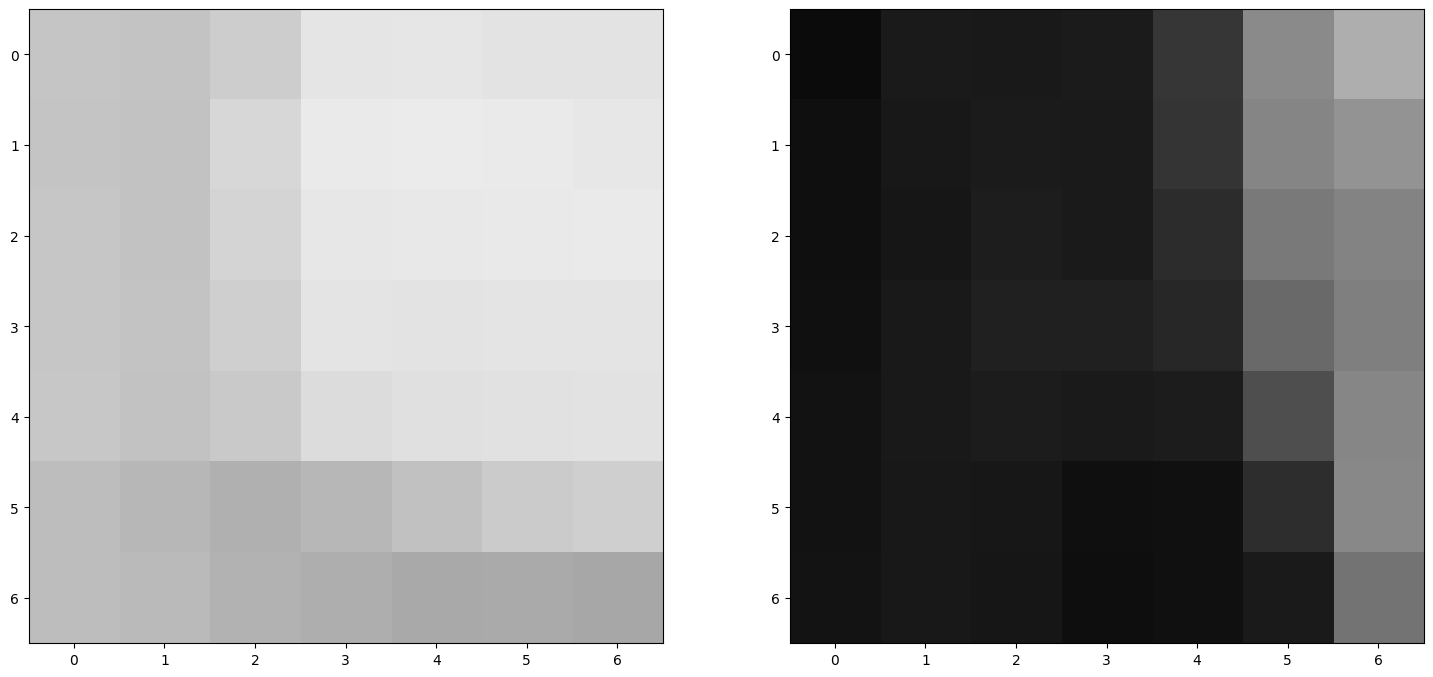

In [ ]:
# load the images
img_left = cv2.imread("nose_left.png")
img_right = cv2.imread("nose_right.png")

# convert images to grayscale for template matching
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)

f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(img_left)
ax_right.imshow(img_right)

In [17]:
def SAD(img_left, img_right): #  def SAD(img_left, img_right, kernel_size, d): d for disparity
    img_new=np.zeros(img_left.shape, dtype=np.int16)
    for i in range(img_left.shape[0]):
        for j in range(img_left.shape[1]):
            """ if (i>=kernel_size-1 and j>=kernel_size-1+d): 
                pixel=0
                for k in range(kernel_size):
                    for l in range(kernel_size):
                        pixel += abs(int(img_left[i-k,j-l])-int(img_right[i-k,j-l-d])) 
                        img_new[i,j]=pixel
                         """
                
            img_new[i,j]=abs(int(img_left[i,j])-int(img_right[i,j]))
    
    return np.sum(img_new) 


In [18]:
nose1=cv2.imread("nose1.png")
nose2=cv2.imread("nose2.png")
nose3=cv2.imread("nose3.png")

nose1 = cv2.cvtColor(nose1, cv2.COLOR_BGR2GRAY)
nose2 = cv2.cvtColor(nose2, cv2.COLOR_BGR2GRAY)
nose3 = cv2.cvtColor(nose3, cv2.COLOR_BGR2GRAY)

diff1=SAD(nose1,nose2)
diff2=SAD(nose2,nose3)
diff3=SAD(nose1,nose3)


print(f"nose 1 vs nose 2: {diff1}")
print(f"nose 2 vs nose 3: {diff2}")
print(f"nose 1 vs nose 3: {diff3}")

nose 1 vs nose 2: 1320
nose 2 vs nose 3: 1509
nose 1 vs nose 3: 1803


Here we see nose 1 and nose 2 are the closest

## Exercise 3

In [ ]:
def find_nose(span, nose_template, kernel_size):
    span=span.copy()
    sad=[]

    for i in range(span.shape[0]):
        for j in range(span.shape[1]):
            if (i == kernel_size-1 and j + kernel_size <= span.shape[1]): #once it is at a corner at 7 height
                img_compare=np.zeros(nose_template.shape, dtype=np.int16)

                for k in range(kernel_size):
                    for l in range(kernel_size):
                        img_compare[k,l]=span[k,j+l]

                sad.append(SAD(img_compare,nose_template))
            else:
                continue

    return sad

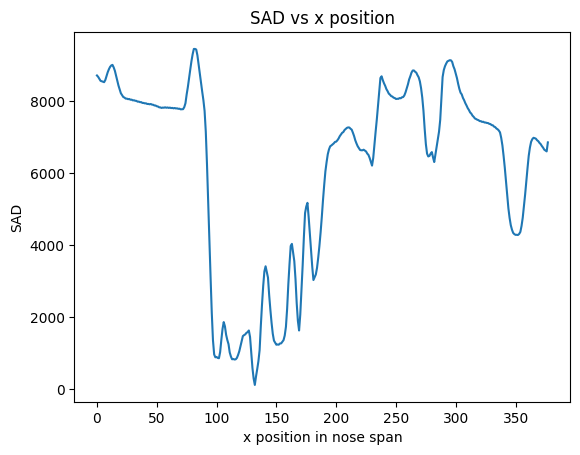

best x: 132


In [25]:
nose_span = cv2.imread("nose_span.png")
nose_span = cv2.cvtColor(nose_span,cv2.COLOR_BGR2GRAY)


template = cv2.imread("nose_left.png")
template = cv2.cvtColor(template,cv2.COLOR_BGR2GRAY)

sad_values = find_nose(nose_span, template, 7)

x_positions = np.arange(len(sad_values))

plt.plot(x_positions, sad_values) 
plt.xlabel("x position in nose span")
plt.ylabel("SAD")
plt.title("SAD vs x position")
plt.show()

best_x = np.argmin(sad_values)

print (f"best x: {best_x}")

In exercise, the nose is found by using the 7x7 nose template over the span from left to right, computing the absoulte difference at each relevant x step. This is saved and then displayed along with x positions. By looking and the minimum value of the graph, we can find the nose's value. The best x is at 132, meaning that the matching nose slice on the span is from x=132 to x=139. A lot of the for loops here could be avoided in the future using np functions, but here it is done for clarity of the exercise, especiaally if a kernel is used. 

## Challenge 

In [29]:
def full_template_matching(img_left, img_right):
    best_values=np.zeros(img_left.shape, dtype=np.int16) # contains the best disparity values for each pixel
    min_val=np.inf  

    for i in range(img_right.shape[0]): # select row 
        if i>2 and i<img_right.shape[0]-3: # centre based approach
            span=img_right[i-3:i+4,:] # create span using the row 

            for j in range(img_left.shape[1]):
                if j>2 and j<img_left.shape[1] - 3:
                    template = img_left[i-3:i+4, j-3:j+4] # template slice

                    vals = find_nose(nose_template = template, kernel_size = 7, span = span)

                    best_x = np.argmin(vals)

                    matched_x = best_x + 3

                    disparity = j - matched_x # j - value with lowest sad

                    best_values[i,j]= disparity

    return best_values
                        
                    


    

In [ ]:
img_left = cv2.imread("tsukuba_left.png")
img_left = cv2.cvtColor(img_left,cv2.COLOR_BGR2GRAY)


img_right = cv2.imread("tsukuba_right.png")
img_right = cv2.cvtColor(img_right,cv2.COLOR_BGR2GRAY)


disparity_map = full_template_matching(img_left=img_left, img_right=img_right)

In [ ]:
plt.imshow(disparity_map, cmap="gray")
plt.colorbar(label="Disparity")
plt.show()